In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [28]:
def mostrar_grafo(G, img_size: tuple[int, int], title: str, position, v_color: str):
  """
  Uma função para mostrar na tela a representação gráfica do grafo
  G        -> the networkx graph object
  img_size -> two integers tuple that dictates the x and y size for the image
  title    -> the figure's title
  position -> G's configuration for the figure render using nx.spring_layout()
  v_color  -> vertex's colors in hex
  """
  plt.figure(figsize=img_size)
  nx.draw(G, position, with_labels=True, node_color=v_color, node_size=1700,
          font_size=9, font_weight="bold", edge_color="#555", width=3)
  plt.title(title)
  plt.show()
  plt.close()

# Questão 1
## Lista de Filmes
- A Odisseia — Christopher Nolan (2026)
- Oppenheimer — Christopher Nolan (2023)
- Tenet — Christopher Nolan (2020)
- Duna — Denis Villeneuve (2021)
- Blade Runner 2049 — Denis Villeneuve (2017)
- O Dublê (The Fall Guy) — David Leitch (2024)

## Lista de Atores
- Tom Holland
- Robert Pattinson
- Zendaya
- Matt Damon
- Ryan Gosling
- Emily Blunt

## Nota: Operações com "sets" (conjuntos) no python
```python
P & Q      # interseção
P - Q      # P \ Q
X | Y      # união
```

## Objetos são atores e dois atores estão relacionados quando atuam em um mesmo filme.

In [31]:
# Solução 1: Lista de Adjacências
# Aqui, no lugar das listas, usamos sets (conjuntos) para facilitar a implementação
# de algoritmos como detecção de cliques, encontrar caminhos, etc.
# Isso se deve ao fato de que operações com sets são basicamente iguais àquelas vistas
# na notação matemática.
atores = {
    "Holland": {"Pattinson", "Zendaya", "Damon"},
    "Pattinson": {"Holland", "Zendaya", "Damon"},
    "Zendaya": {"Holland", "Pattinson", "Damon"},
    "Damon": {"Holland", "Pattinson", "Zendaya", "Blunt"},
    "Blunt": {"Damon", "Gosling"},
    "Gosling": {"Blunt"}
}

# Solução 1.5: Usando Hash Map, com a chave sendo a aresta
# (sendo assim, a aresta entre u e v é codificado como "u v")

atores_2 = {
    "Holland Pattinson": 1,
    "Holland Zendaya": 1,
    "Holland Damon": 1,
    "Pattinson Zendaya": 1,
    "Pattinson Damon": 1,
    "Zendaya Damon": 1,
    "Damon Blunt": 1,
    "Blunt Goslin": 1
}

G_atores_2 = nx.Graph()

for par, peso in atores_2.items():
  u, v = par.split()
  G_atores_2.add_edge(u, v, weight=peso)

# Solução 2: matriz de vizinhanças
lista_atores = ["Holland", "Pattinson", "Zendaya", "Damon", "Blunt", "Gosling"]

mapeamento = np.array([
    [0, 1, 1, 1, 0, 0],
    [1, 0, 1, 1, 0, 0],
    [1, 1, 0, 1, 0, 0],
    [1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1],
    [0, 0, 0, 0, 1, 0]
])

# Criando grafo com lib para visualização
G_atores_dict = nx.Graph(atores)
G_atores_matr = nx.from_numpy_array(mapeamento)
G_atores_matr = nx.relabel_nodes(G_atores_matr, dict(enumerate(lista_atores)))


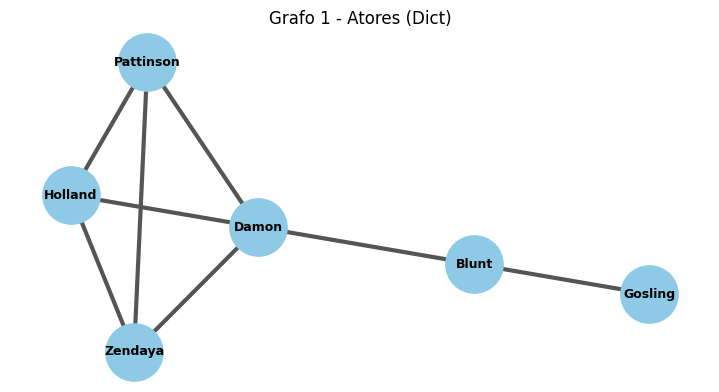

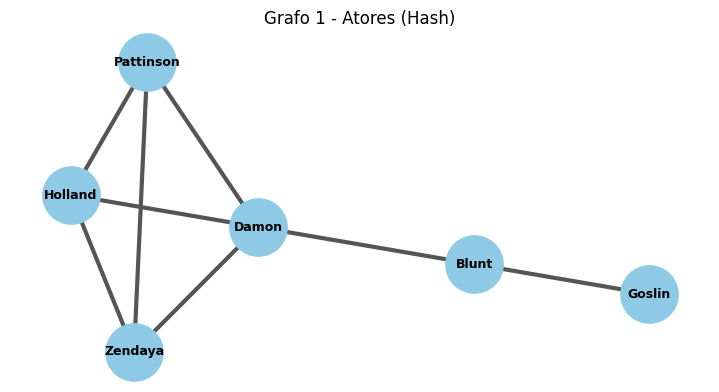

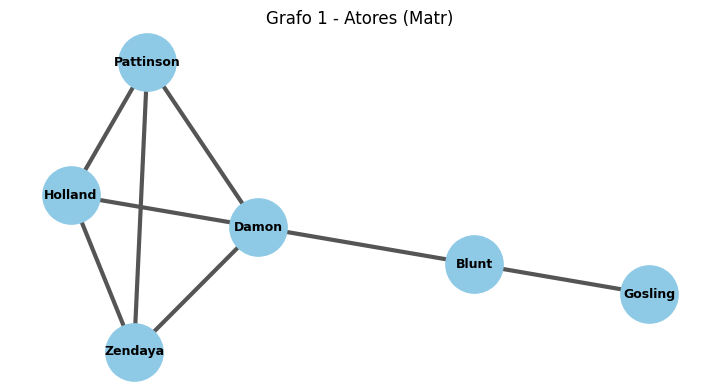

In [32]:
mostrar_grafo(G_atores_dict, (7,3.5), "Grafo 1 - Atores (Dict)", nx.spring_layout(G_atores_dict, seed=11), "#8ecae6")
print()
mostrar_grafo(G_atores_2, (7,3.5), "Grafo 1 - Atores (Hash)", nx.spring_layout(G_atores_2, seed=11), "#8ecae6")
print()
mostrar_grafo(G_atores_matr, (7,3.5), "Grafo 1 - Atores (Matr)", nx.spring_layout(G_atores_matr, seed=11), "#8ecae6")

## Objetos são filmes e dois filmes estão relacionados quando um mesmo diretor dirigiu os dois filmes.

In [6]:
filmes_lista = ["A Odisseia", "Oppenheimer", "Tenet", "Duna", "Blade Runner 2049", "O Dublê"]

matriz_adj = np.array([
    [0,1,1,0,0,0],
    [1,0,1,0,0,0],
    [1,1,0,0,0,0],
    [0,0,0,0,1,0],
    [0,0,0,1,0,0],
    [0,0,0,0,0,0]
])

G_filmes_matr = nx.from_numpy_array(matriz_adj)
G_filmes_matr = nx.relabel_nodes(G_filmes_matr, dict(enumerate(filmes_lista)))

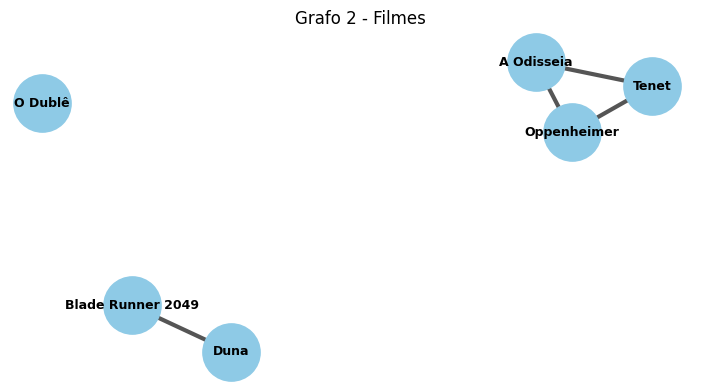

In [7]:
mostrar_grafo(G_filmes_matr, (7,3.5), "Grafo 2 - Filmes", nx.spring_layout(G_filmes_matr, seed=3, k=1.0, scale=3.0), "#8ecae6")

## Objetos são atores e filmes. O relacionamento de interesse é um ator atuar em um filme.

Após um momento de interpretação, é simples notar que estamos modelando o elenco de um filme com grafos aqui. Sendo assim, usaremos a forma de dicionário para sua implementação, afim de facilitar o entendimento humano.

In [8]:
# Lista de adjacência
elenco = {
    "A Odisseia": ["Pattinson", "Damon", "Zendaya", "Holland"],
    "Oppenheimer": ["Blunt", "Damon"],
    "Tenet": ["Pattinson"],
    "Duna": ["Zendaya"],
    "Blade Runner 2049": ["Gosling"],
    "O Dublê": ["Gosling", "Blunt"]
}

G_elenco = nx.Graph(elenco)

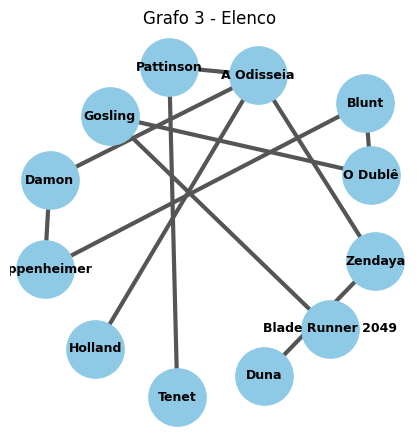

In [9]:
mostrar_grafo(G_elenco, (4,4), "Grafo 3 - Elenco", nx.spring_layout(G_elenco, seed=1, k=3.0, scale=3.0), "#8ecae6")

Por definição de "elenco", é fácil notar que é um grafo bipartido. Sendo assim, modificando a forma de exibição do grafo para facilitar essa análise, temos:

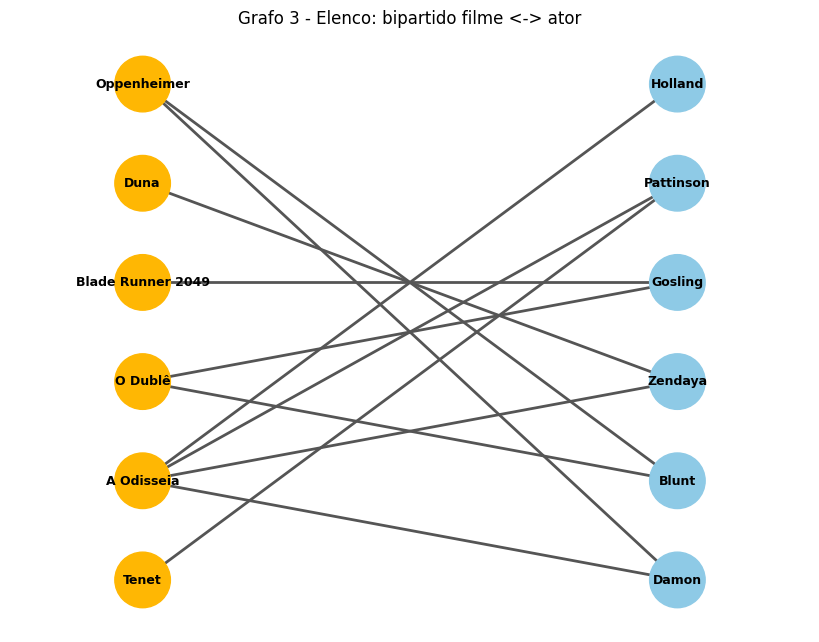

In [10]:
pos_b = nx.bipartite_layout(G_elenco, list(elenco.keys()))
cores_b = ["#ffb703" if n in elenco else "#8ecae6" for n in G_elenco.nodes()]
plt.figure(figsize=(8, 6))
nx.draw(G_elenco, pos_b, with_labels=True, node_color=cores_b, node_size=1600,
        font_size=9, font_weight="bold", edge_color="#555", width=2)
plt.title("Grafo 3 - Elenco: bipartido filme <-> ator")
plt.margins(x=0.18)
plt.show()
plt.close()

# Questão 2
Para dar continuidade à lista, vamos fazer uma implementação rápida dos tipos, tanto para grafos de listas (no caso, conjuntos) de adjacências, bem como para matrizes de adjacências e alguns métodos simples para facilitar nossa implementação de algoritmos.

Aqui, definimos os seguintes tipos:
- `Grafo`
- `GrafoListaAdj(Grafo)`
- `GrafoMatrizAdj(Grafo)`

Onde, explicitamos que `GrafoListaAdj` e `GrafoMatrizAdj` são tipos que herdam Grafo, utilizando do polimorfismo presente no python para especializar cada um deles.

Dentro de cada um, temos os seguintes métodos:
- `Grafo`
  - `vertices` (abstrato)
  - `__len__` (abstrato)
  - `__contains__` (abstrato)
  - `__iter__` (abstrato)
  - `__getitem__` (abstrato)
  - `__repr__` (abstrato)
  - `eh_clique`
- `GrafoListaAdj` implementa todas abstrações de `Grafo`
- `GrafoMatrizAdj` implementa todas abstrações de `Grafo`

## Complexidade (Big O)
### Matriz de Adjacências (`GrafoMatrizAdj`)
| Operação | Tempo (Impl.) | Espaço (Impl.) | Tempo (Esperado) | Espaço (Esperado) |
| -------- | ----- | ------ | ------------- | ---------------- |
| len(g) ou \|V\| |	O(1) |	O(1) |	O(1) |	O(1) |
| v in g — é vértice? |	O(1) |	O(1) |	O(1) |	O(1) |
| Iterar vértices	| O(n) |	O(1)	| O(n)	| O(1) |
| Inserir aresta	| O(1) |	O(1)	| O(1)	| O(1) |
| Remover aresta	| O(1) |	O(1)	| O(1)	| O(1) |
| Testar adjacência (tem_aresta)	| O(1) |	O(1)	| O(1)	| O(1) |
| Listar vizinhos de v (g[v])	| O(n) |	O(g_max)	| O(n)	| O(g_max) |
| Vértice de maior grau	| O(n²) |	O(1)	| O(n²)	| O(1) |
| Armazenamento da estrutura	| —	| O(n²) |	—	| O(n²) |


### Lista de Adjacência (`GrafoListaAdj`)
| Operação | Tempo (Impl.) | Espaço (Impl.) | Tempo (Esperado) | Espaço (Esperado) |
| -------- | ----- | ------ | ------------- | ---------------- |
| len(g) ou \|V\|	| O(1)	| O(1)	| O(1)	| O(1) |
| v in g — é vértice?	| O(1)	| O(1)	| O(1)	| O(1) |
| Iterar vértices	| O(n)	| O(1)	| O(n)	| O(1) |
| Inserir aresta	| O(1) | ᵃ |	O(1) | ᵃ	| O(1)	| O(1) |
| Remover aresta	| O(g_max)	| O(1)	| O(g_max)	| O(1) |
| Testar adjacência (tem_aresta)	| O(g_max)	| O(1)	| O(g_max)	| O(1) |
| Listar vizinhos de v (g[v]) |	O(g_max) | ᵇ |	O(1) | ᵇ	| O(g_max)	| O(1) |
| Vértice de maior grau |	O(n) | ᶜ	| O(1)	| O(m)	| O(1) |
| Armazenamento da estrutura |	— |	O(n+m) |	— |	O(n+m) |

ᵃ Inserir aresta — nossa list é array dinâmico, então append é O(1) amortizado (a realocação pontual O(n) é diluída). O esperado O(1) da teoria é o head-insert de uma lista encadeada pura, esse não-amortizado. Mesmo símbolo O(1), origem diferente.

ᵇ Listar vizinhos — g[v] devolve a referência da lista interna em O(1), sem copiar (por isso espaço O(1)); enumerar os vizinhos é O(g_max), que é o custo listado. A matriz, em contraste, precisa materializar a lista varrendo a linha, daí o O(g_max) de espaço lá.

ᶜ Vértice de maior grau — a única divergência de tempo. len() de uma list é O(1), então percorremos só os n vértices → O(n). O esperado O(m) supõe contar o grau percorrendo cada cadeia (encadeada sem tamanho cacheado). Se a doc precisar bater O(m) ao pé da letra, trocar o key por uma contagem que percorre resolve — ao custo de ficar propositalmente mais lento.


### Conclusão
Como podemos ver, as nossas implementações customizadas provêm mesma complexidade algoritmica para quase todas as operações em relação àquelas impostas pela teoria. Sendo assim, podemos utilizar nossos tipos customizados sem muitos danos colaterais à análises de complexidade de algoritmos.

In [11]:
from abc import ABC, abstractmethod
from collections.abc import Iterable, Iterator
from itertools import combinations

Vertice = str
Aresta = tuple[Vertice, Vertice]

class Grafo(ABC):
  """
  A assinatura que todas implementações futuras de tipos de grafos deverão seguir
  """

  @property
  @abstractmethod
  def vertices(self) -> set[Vertice]: ...

  @abstractmethod
  def __len__(self) -> int:
    """|V| - número de vértices"""
    ...

  @abstractmethod
  def __contains__(self, v: Vertice) -> bool: ...

  @abstractmethod
  def __iter__(self) -> Iterator[Vertice]: ...

  @abstractmethod
  def __getitem__(self, u: Vertice) -> set[Vertice]: ...

  @abstractmethod
  def inserir_aresta(self, u: Vertice, w: Vertice) -> None: ...

  @abstractmethod
  def remover_aresta(self, u: Vertice, w: Vertice) -> None: ...

  @abstractmethod
  def tem_aresta(self, u: Vertice, w: Vertice) -> bool: ...

  @abstractmethod
  def vertice_maior_grau(self) -> Vertice: ...

  def __repr__(self) -> str:
      return f"{type(self).__name__}(|V|={len(self)})"

  def eh_clique(self, S: set[Vertice] | None = None) -> bool:
    """S é clique se cada vértice de S tem todos os OUTROS de S como
        vizinhos. Sem argumento, testa o grafo inteiro."""
    if S is None:
      S = self.vertices
    return all(self.tem_aresta(u, w) for u, w in combinations(S, 2))



class GrafoListaAdj(Grafo):
  """Lista de adjacências clássica: cada vértice -> lista sequencial de vizinhos."""

  def __init__(self, vertices: Iterable[Vertice], arestas: Iterable[Aresta] = ()):
    self._adj: dict[Vertice, list[Vertice]] = {v: [] for v in vertices}
    for u, w in arestas:
      self.inserir_aresta(u, w)

  @property
  def vertices(self) -> set[Vertice]:
    return set(self._adj)

  def __len__(self) -> int: # O(1)
    return len(self._adj) # |V|

  def __contains__(self) -> bool: # O(1): chave do dicionário
    return v in self._adj

  def __iter__(self) -> Iterator[Vertice]:
    return iter(self._adj)

  def __getitem__(self, u: Vertice) -> set[Vertice]: # listar vizinhos: percorrer - O(g_max)
    return self._adj[u]

  def inserir_aresta(self, u: Vertice, w: Vertice) -> None: # O(1): aproximação, já que python não tem linked list pura na biblioteca padrão
    self._adj[u].append(w)
    self._adj[w].append(u)

  def remover_aresta(self, u: Vertice, w: Vertice) -> None: # O(g_max): busca O(g_max) + remoção O(1)
    self._adj[u].remove(w)
    self._adj[w].remove(u)

  def tem_aresta(self, u: Vertice, w: Vertice) -> bool: # O(g_max): busca linear
    return w in self._adj[u]

  def vertice_maior_grau(self) -> Vertice: # O(n), len é O(1)
    return max(self._adj, key=lambda v: len(self._adj[v]))

class GrafoMatrizAdj(Grafo):
  """Matriz n x n. Rótulo -> índice via self._indice."""

  def __init__(self, vertices: Iterable[Vertice], arestas: Iterable[Aresta] = ()):
    self._vertices: list[Vertice] = list(vertices)
    self._indice: dict[Vertice, int] = {
        v: i for i, v in enumerate(self._vertices)
    }
    n = len(self._vertices)
    self._M: list[list[int]] = [[0] * n for _ in range(n)]
    for u, w in arestas:
      self.inserir_aresta(u, w)

  @property
  def vertices(self) -> set[Vertice]:
    return set(self._vertices)

  def __len__(self) -> int: # O(1)
    return len(self._vertices)

  def __contains__(self) -> bool: # O(1)
    return v in self._indice

  def __iter__(self) -> Iterator[Vertice]:
    return iter(self._vertices)

  def __getitem__(self, u: Vertice) -> set[Vertice]: # listar vizinhos: O(n)
    i = self._indice[u]
    return {self._vertices[j] for j, tem in enumerate(self._M[i]) if tem}

  def inserir_aresta(self, u: Vertice, w: Vertice) -> None: # O(1)
    i, j = self._indice[u], self._indice[w]
    self._M[i][j] = self._M[j][i] = 1

  def remover_aresta(self, u: Vertice, w: Vertice) -> None: # O(1)
    i, j = self._indice[u], self._indice[w]
    self._M[i][j] = self._M[j][i] = 0

  def tem_aresta(self, u: Vertice, w: Vertice) -> bool: # O(1)
    return self._M[self._indice[u]][self._indice[w]] == 1

  def vertice_maior_grau(self) -> Vertice: # O(n^2): soma cada linha
    return max(self._vertices, key=lambda v: sum(self._M[self._indice[v]]))

Reimplementando os grafos do exercício usando essas suas estruturas de dados, temos:

In [12]:
vertices_atores = {"Holland", "Pattinson", "Zendaya", "Damon", "Blunt", "Gosling"}
arestas_atores  = [
    ("Gosling", "Blunt"), ("Blunt", "Damon"), ("Damon", "Holland"),
    ("Damon", "Zendaya"), ("Damon", "Pattinson"), ("Holland", "Zendaya"),
    ("Holland", "Pattinson"), ("Pattinson", "Zendaya")
 ]
atores_lista = GrafoListaAdj(vertices_atores, arestas_atores)
atores_matriz = GrafoMatrizAdj(vertices_atores, arestas_atores)

vertices_filmes = {"A Odisseia", "Oppenheimer", "Tenet", "Duna", "Blade Runner 2049", "O Dublê"}
arestas_filmes  = [
    ("A Odisseia", "Oppenheimer"), ("A Odisseia", "Tenet"), ("Oppenheimer", "Tenet"),
    ("Duna", "Blade Runner 2049")
]
filmes_lista = GrafoListaAdj(vertices_filmes, arestas_filmes)
filmes_matriz = GrafoMatrizAdj(vertices_filmes, arestas_filmes)

vertices_elenco = vertices_atores | vertices_filmes
arestas_elenco  = [
    ("A Odisseia", "Holland"), ("A Odisseia", "Zendaya"), ("A Odisseia", "Pattinson"),
    ("A Odisseia", "Damon"), ("Oppenheimer", "Blunt"), ("Oppenheimer", "Damon"),
    ("O Dublê", "Blunt"), ("O Dublê", "Gosling"), ("Tenet", "Pattinson"),
    ("Duna", "Zendaya"), ("Blade Runner 2049", "Gosling")
]
elenco_lista = GrafoListaAdj(vertices_elenco, arestas_elenco)
elenco_matriz = GrafoMatrizAdj(vertices_elenco, arestas_elenco)

## Maior Clique nos grafos
Pseudo-código:
```python
melhor = None
for subconjunto in Grafo:
  if pares de arestas do subconjunto: # Se todos os pares são arestas
    if |subconjunto| > |melhor|:
      melhor = subconjunto
return melhor
```

In [13]:
from itertools import chain, combinations

def obtem_todos_subconjuntos(conjunto: set[str]) -> list[set[str]]:
  s = list(list(conjunto))
  return chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))

In [14]:
def encontra_maior_clique(grafo: GrafoListaAdj | GrafoMatrizAdj) -> set[Vertice] | None:
  melhor = []
  subconjuntos: list[set[Vertice]] = obtem_todos_subconjuntos(grafo.vertices)
  for subconjunto in subconjuntos:
    pares = list(combinations(subconjunto, 2))
    todos_conectados = True
    for par in pares:
      if not grafo.tem_aresta(par[0], par[1]):
        todos_conectados = False
    if todos_conectados and (len(melhor) < len(subconjunto)):
      melhor = subconjunto
  return melhor

In [15]:
from typing import Callable

def usa_funcao_com_grafos(func: Callable, texto: str):
  """Usa a func em todas variantes dos grafos da q1 e usa o texto para customizar os prints"""

  func_atores_lista = func(atores_lista)
  func_atores_matriz = func(atores_matriz)

  print("Grafo de Atores")
  print(f"{texto} usando lista: {func_atores_lista}")
  print(f"{texto} usando matriz: {func_atores_matriz}")

  func_filmes_lista = func(filmes_lista)
  func_filmes_matriz = func(filmes_matriz)

  print("Grafo de Filmes")
  print(f"{texto} usando lista: {func_filmes_lista}")
  print(f"{texto} usando matriz: {func_filmes_matriz}")

  func_elenco_lista = func(elenco_lista)
  func_elenco_matriz = func(elenco_matriz)

  print("Grafo de Elenco")
  print(f"{texto} usando lista: {func_elenco_lista}")
  print(f"{texto} usando matriz: {func_elenco_matriz}")

In [16]:
usa_funcao_com_grafos(encontra_maior_clique, "Maior clique")

Grafo de Atores
Maior clique usando lista: ('Damon', 'Zendaya', 'Pattinson', 'Holland')
Maior clique usando matriz: ('Damon', 'Zendaya', 'Pattinson', 'Holland')
Grafo de Filmes
Maior clique usando lista: ('Tenet', 'A Odisseia', 'Oppenheimer')
Maior clique usando matriz: ('Tenet', 'A Odisseia', 'Oppenheimer')
Grafo de Elenco
Maior clique usando lista: ('Tenet', 'Pattinson')
Maior clique usando matriz: ('Tenet', 'Pattinson')


## Diâmetro de um grafo
O diâmetro de um grafo é a maior distância possível de se percorrer em um grafo.

In [30]:
from collections import deque

def encontra_diametro(grafo: GrafoListaAdj | GrafoMatrizAdj) -> int:
  diametro_maximo: int = 0
  vertices: set[Vertice] = grafo.vertices

  for vertice_inicial in vertices:
    # Fila contém (vertice_atual, distancia_da_origem)
    fila = deque([(vertice_inicial, 0)])
    visitados: set[Vertice] = {vertice_inicial}
    maior_distancia_local: int = 0

    while fila:
      atual, distancia = fila.popleft()

      if distancia > maior_distancia_local:
        maior_distancia_local = distancia

      vizinhos: list[Vertice] = grafo[atual]
      for vizinho in vizinhos:
        if vizinho not in visitados:
          visitados.add(vizinho)
          fila.append((vizinho, distancia + 1))

    if len(visitados) < len(grafo):
        return float('inf')

    if maior_distancia_local > diametro_maximo:
      diametro_maximo = maior_distancia_local


  return diametro_maximo

In [31]:
usa_funcao_com_grafos(encontra_diametro, "Diâmetro")

Grafo de Atores
Diâmetro usando lista: 3
Diâmetro usando matriz: 3
Grafo de Filmes
Diâmetro usando lista: inf
Diâmetro usando matriz: inf
Grafo de Elenco
Diâmetro usando lista: 8
Diâmetro usando matriz: 8


## Clico Hamiltoniano

In [19]:
def encontra_ciclo_hamiltoniano(grafo: GrafoListaAdj | GrafoMatrizAdj) -> list[Vertice] | None:
    vertices = list(grafo.vertices)
    if not vertices:
        return None

    vertice_inicial = vertices[0]
    total_vertices = len(vertices)

    # Chave: (conjunto_de_vertices_visitados, ultimo_vertice_do_caminho)
    cache = {
        (frozenset([vertice_inicial]), vertice_inicial): [vertice_inicial]
    }

    # Construímos os caminhos iterativamente: tamanho 2, tamanho 3, até V
    for tamanho_atual in range(2, total_vertices + 1):
        novo_cache = {}

        # Inspeciona todos os caminhos válidos do tamanho anterior
        for (visitados, ultimo), caminho_percorrido in cache.items():

            # Tenta expandir o caminho para os vizinhos do último vértice
            for vizinho in grafo[ultimo]:
                if vizinho not in visitados:
                    novos_visitados = visitados | frozenset([vizinho])
                    novo_estado = (novos_visitados, vizinho)

                    # Se já chegamos neste exato estado
                    # por outro caminho, a atribuição abaixo simplesmente sobrescreve.
                    # Isso poda milhões de permutações inúteis.
                    novo_cache[novo_estado] = caminho_percorrido + [vizinho]

        # Substitui o cache antigo pelo cache da nova camada
        cache = novo_cache

    # Ao final do loop, o cache contém apenas caminhos que passaram por todos os vértices.
    # Agora só precisamos checar qual deles consegue fechar o ciclo de volta à origem.
    for (visitados, ultimo), caminho_completo in cache.items():
        if grafo.tem_aresta(ultimo, vertice_inicial):
            caminho_completo.append(vertice_inicial)
            return caminho_completo

    return None

In [20]:
usa_funcao_com_grafos(encontra_ciclo_hamiltoniano, "Ciclo Hamiltoniano")

Grafo de Atores
Ciclo Hamiltoniano usando lista: None
Ciclo Hamiltoniano usando matriz: None
Grafo de Filmes
Ciclo Hamiltoniano usando lista: None
Ciclo Hamiltoniano usando matriz: None
Grafo de Elenco
Ciclo Hamiltoniano usando lista: None
Ciclo Hamiltoniano usando matriz: None


Como para todos os grafos do exercício, o algoritmo acusa que não há caminho hamiltoniano, crio abaixo um grafo que facilmente por inspeção conseguimos notar um ciclo e passo pelo algoritmo para checar se ele é ou não capaz de identificar corretamente os ciclos.

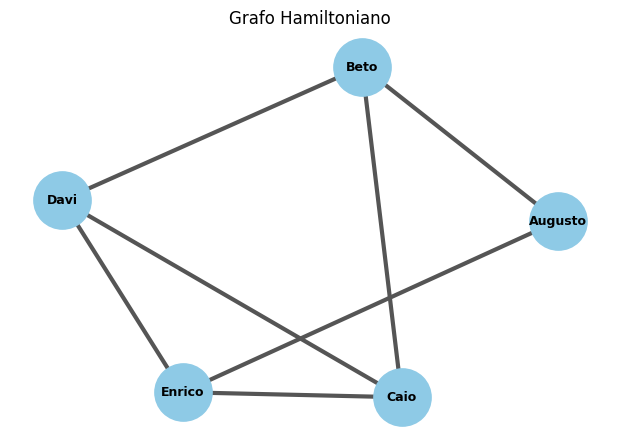

In [21]:
vertices = {'Augusto', 'Beto', 'Caio', 'Davi', 'Enrico'}
arestas = [
    ('Augusto', 'Beto'), ('Augusto', 'Enrico'), ('Beto', 'Caio'), ('Beto', 'Davi'),
    ('Caio', 'Davi'), ('Caio', 'Enrico'), ('Davi', 'Enrico')
    ]
hamiltoniano_lista = GrafoListaAdj(vertices, arestas)
hamiltoniano_matriz = GrafoMatrizAdj(vertices, arestas)

g_hamiltoniano = nx.Graph(arestas)
mostrar_grafo(g_hamiltoniano, (6,4), "Grafo Hamiltoniano", nx.spring_layout(g_hamiltoniano, seed=4, k=3.0, scale=3.0), "#8ecae6")

In [22]:
print("Grafo Hamiltoniano")
print(f"Ciclo Hamiltoniano para lista {encontra_ciclo_hamiltoniano(hamiltoniano_lista)}")
print(f"Ciclo Hamiltoniano para matriz {encontra_ciclo_hamiltoniano(hamiltoniano_matriz)}")

Grafo Hamiltoniano
Ciclo Hamiltoniano para lista ['Enrico', 'Augusto', 'Beto', 'Caio', 'Davi', 'Enrico']
Ciclo Hamiltoniano para matriz ['Beto', 'Augusto', 'Enrico', 'Davi', 'Caio', 'Beto']


## Circuito Euleriano
Como visto em sala, basta garantir que, para todos os vértices de G, temos grau(V) par.

In [23]:
def identifica_circuito_euleriano(grafo: GrafoListaAdj | GrafoMatrizAdj) -> bool:
  for vertice in grafo.vertices:
    if len(grafo[vertice]) % 2 != 0:
      return False
  return True

In [32]:
def encontra_circuito_euleriano(grafo: GrafoListaAdj | GrafoMatrizAdj) -> list[Vertice]:
  vertices: list[Vertice] = list(grafo.vertices)

  # Não há euleriano para grafos que contenham vertice com grau ímpar
  for vertice in vertices:
    if len(grafo[vertice]) % 2 == 1:
      return None

  vizinhos = {v: list(grafo[v]) for v in vertices}

  pilha_atual = [vertices[0]]
  circuito_final = []

  while pilha_atual:
    atual = pilha_atual[-1]

    if vizinhos[atual]:
      vizinho = vizinhos[atual].pop()
      vizinhos[vizinho].remove(atual)


      pilha_atual.append(vizinho)
    else:
      circuito_final.append(pilha_atual.pop())

  return circuito_final[::-1]

In [33]:
usa_funcao_com_grafos(encontra_circuito_euleriano, "Circuito Euleriano")

Grafo de Atores
Circuito Euleriano usando lista: None
Circuito Euleriano usando matriz: None
Grafo de Filmes
Circuito Euleriano usando lista: None
Circuito Euleriano usando matriz: None
Grafo de Elenco
Circuito Euleriano usando lista: None
Circuito Euleriano usando matriz: None


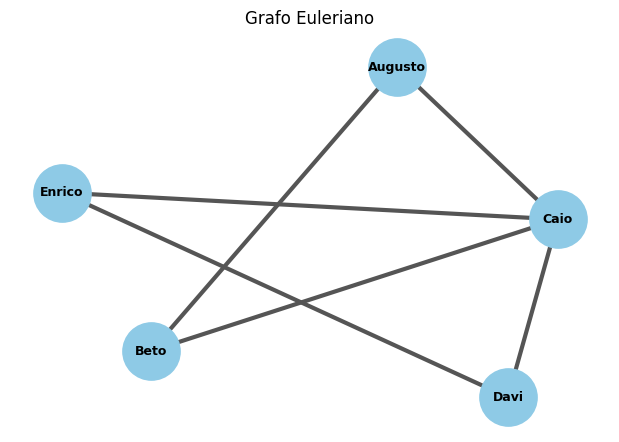

In [26]:
vertices = {'Augusto', 'Beto', 'Caio', 'Davi', 'Enrico'}

# Vértice central: Caio (Grau 4)
# Vértices das pontas: Augusto, Beto, Davi, Enrico (Grau 2)
arestas = [
    # Primeiro ciclo (Triângulo esquerdo)
    ('Caio', 'Augusto'), ('Augusto', 'Beto'), ('Beto', 'Caio'),

    # Segundo ciclo (Triângulo direito)
    ('Caio', 'Davi'), ('Davi', 'Enrico'), ('Enrico', 'Caio')
]

euleriano_lista = GrafoListaAdj(vertices, arestas)
euleriano_matriz = GrafoMatrizAdj(vertices, arestas)

g_euleriano = nx.Graph(arestas)

# Utilizando a convenção de plotagem
mostrar_grafo(
    g_euleriano,
    (6, 4),
    "Grafo Euleriano",
    nx.spring_layout(g_euleriano, seed=4, k=3.0, scale=3.0),
    "#8ecae6"
)

In [27]:
print("Grafo Euleriano")
print(f"Ciclo Euleriano para lista {encontra_circuito_euleriano(euleriano_lista)}")
print(f"Ciclo Euleriano para matriz {encontra_circuito_euleriano(euleriano_matriz)}")

Grafo Euleriano
Ciclo Euleriano para lista ['Enrico', 'Caio', 'Beto', 'Augusto', 'Caio', 'Davi', 'Enrico']
Ciclo Euleriano para matriz ['Beto', 'Caio', 'Enrico', 'Davi', 'Caio', 'Augusto', 'Beto']


## Grafo Bipartido
Para decidir se um grafo é ou não bipartido, devemos tentar separar um vértice de todos seus vizinhos, colocando-os em classes diferentes (como colorir os vértices) e repetir isso para todos os vértices. Se não cairmos em contradição para nenhum vértice, então o grafo é bipartido. Caso contrário, ele não é bipartido.

In [28]:
from collections import deque

def eh_bipartido(grafo: GrafoListaAdj | GrafoMatrizAdj) -> bool:
  vertices = list(grafo.vertices)
  if not vertices:
    return True

  # 'particao' armazena a cor atribuída (0 ou 1) para cada vértice visitado.
  # Um vértice que não está em 'particao' é considerado não visitado/não colorido.
  particao = {}
  fila = deque()

  # Itera sobre todos os vértices para lidar com grafos desconectados
  for vertice_inicial in vertices:
    if vertice_inicial not in particao: # Inicia a BFS apenas se o vértice ainda não foi colorido
      fila.append((vertice_inicial, 0)) # (vértice, cor)
      particao[vertice_inicial] = 0 # Atribui a cor 0 ao vértice inicial

      while fila:
        vertice_atual, cor_atual = fila.popleft()

        for vizinho in grafo[vertice_atual]:
          if vizinho not in particao:
            # Se o vizinho não foi colorido, atribui a cor oposta e adiciona à fila
            cor_oposta = 1 - cor_atual
            particao[vizinho] = cor_oposta
            fila.append((vizinho, cor_oposta))
          elif particao[vizinho] == cor_atual:
            # Se o vizinho já foi colorido e tem a mesma cor que o vertice_atual,
            # então o grafo não é bipartido
            return False
  return True

In [29]:
usa_funcao_com_grafos(eh_bipartido, "Grafo Bipartido")

Grafo de Atores
Grafo Bipartido usando lista: False
Grafo Bipartido usando matriz: False
Grafo de Filmes
Grafo Bipartido usando lista: False
Grafo Bipartido usando matriz: False
Grafo de Elenco
Grafo Bipartido usando lista: True
Grafo Bipartido usando matriz: True


# Questão 3

## 1. Atores Arbitrários
Número de Bacon para 3 atores brasileiros arbitrários:
- Wagner Moura: 2
  - Wagner Moura -(The Gray Man)- Billy Bob Thornton -(Jayne Mansfield's Car)- Kevin Bacon
- Juliana Paes: 2
  - Juliana Paes -(The Surgeon of the Rusty Knife)- James Faulkner -(X-Men: First Class)- Kevin Bacon
- Felipe Abib: 3
  - Felipe Abib -(Vai Que Dá Certo)- Lúcio Mauro Filho -(Amazonia)- Martin Sheen -(8)- Kevin Bacon

## 2. Ator Brasileiro com maior Bacon finito
O maior número de bacon que eu fui capaz de encontrar é 3. Para ele, encontrei diversos artistas, como:
- Felipe Abib
- Alcione
- Eduardo Sterblitch
- Paulo Vieira



# Questão 4
Usando a aplicação web https://www.underleaf.ai/tools/erdos-number para consultar o número de Erdös para diferentes professores da UFRJ com os quais já tive aula, noto que, para aqueles que estão declarados no banco de dados da aplicação, o menor número de Erdös que fui capaz de encontrar é **3**.

Sendo assim, meu número de Erdös, pela definição do enunciado é **3 + 1 = 4**.

# Questão 5
para resolver esta questão, vamos implementar um crawler com python que começa no site inicial da ufrj (www.ufrj.br) e finaliza a execução ao listar o site do mit (www.mit.edu) em seu grafo.

## Modelagem do Crawler:
- Objetos: links
- Relacionamentos: referências em uma página web

### Web Crawler Bidirecional: Mapeamento de Grafo (UFRJ ⇄ MIT)

Implementamos um crawler assíncrono para encontrar o menor caminho hipertextual entre o portal da **UFRJ** (`www.ufrj.br`) e o do **MIT** (`www.mit.edu`) através de uma **Busca Bidirecional Heurística (Best-First Search)**.

### Arquitetura e Recursos
* **Concorrência:** `asyncio` e `aiohttp` para requisições assíncronas não bloqueantes de alta performance.
* **Persistência:** Banco relacional **SQLite** local operando em modo WAL (`Write-Ahead Logging`) para inserções em lotes (*batching*) sem overhead excessivo de I/O.
* **Compatibilidade Colab:** Aplicação do patch `nest_asyncio` para rodar múltiplos loops assíncronos no IPython.
* **Polidez:** Rate limiting dinâmico por domínio com fila de espera.
* **Reconstrução de Caminho:** Resolução via grafo direcionado com `NetworkX`.


## 1. Configuração do Ambiente e Inicialização do Banco de Dados

In [13]:
import asyncio
import re
import sqlite3
import time
from collections import defaultdict
from typing import Dict, List, Optional, Set, Tuple
from urllib.parse import urljoin, urlparse, urldefrag


import aiohttp
from bs4 import BeautifulSoup, XMLParsedAsHTMLWarning
import nest_asyncio
import networkx as nx
import warnings

# Ignora o aviso específico quando o BeautifulSoup processa XML como HTML
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

# Habilita suporte a loops de eventos assíncronos aninhados no Colab
nest_asyncio.apply()

# ------------------------------------------------------------------------------
# CONSTANTES E PARÂMETROS GLOBAIS DE EXECUÇÃO
# ------------------------------------------------------------------------------
DB_FILE = "/content/crawl_graph.db"
START_URL = "https://www.ufrj.br"
TARGET_URL = "https://www.mit.edu"

MAX_NODES = 500_000                  # Limite rígido de nós explorados
MAX_RUNTIME_SECONDS = 5.5 * 3600      # 5h30min de limite de tempo
BATCH_COMMIT_SIZE = 500              # Tamanho do lote para commits no SQLite
DOMAIN_COOLDOWN_SECONDS = 1.5         # Intervalo mínimo de polidez entre requisições ao mesmo domínio
NUM_WORKERS_PER_DIRECTION = 5        # Quantidade de workers assíncronos por sentido (Forward / Backward)

USER_AGENT = "AcademicGraphCrawler/1.0 (+https://github.com/academic-crawler)"
BRIDGE_KEYWORDS = ("international", "exchange", "research", "global", "partners")


# ------------------------------------------------------------------------------
# INICIALIZAÇÃO DO BANCO DE DADOS RELACIONAL (SQLite)
# ------------------------------------------------------------------------------
def init_db(db_path: str = DB_FILE) -> sqlite3.Connection:
    """Inicializa as tabelas de nós e arestas com índices otimizados e modo WAL."""
    conn = sqlite3.connect(db_path, isolation_level=None)
    with conn:
        conn.execute("PRAGMA journal_mode=WAL;")
        conn.execute("PRAGMA synchronous=NORMAL;")

        # Tabela de nós
        conn.execute("""
            CREATE TABLE IF NOT EXISTS nodes (
                url TEXT PRIMARY KEY,
                domain TEXT,
                visited INTEGER DEFAULT 0,
                score REAL
            )
        """)

        # Tabela de arestas direcionadas (origem -> destino)
        conn.execute("""
            CREATE TABLE IF NOT EXISTS edges (
                source_url TEXT,
                target_url TEXT,
                PRIMARY KEY (source_url, target_url)
            )
        """)

        # Índices para acelerar buscas e reconstrução do grafo
        conn.execute("CREATE INDEX IF NOT EXISTS idx_edges_src ON edges(source_url)")
        conn.execute("CREATE INDEX IF NOT EXISTS idx_edges_tgt ON edges(target_url)")
    return conn

# Inicializa o banco de dados local
db_conn = init_db()
print("[+] Banco SQLite inicializado com sucesso em:", DB_FILE)

[+] Banco SQLite inicializado com sucesso em: /content/crawl_graph.db


## 2. Normalização de URLs e Motor Heurístico

Para evitar ciclos infinitos causados por fragmentos de página (`#`) ou barras finais duplicadas, padronizamos as URLs.

A função de heurística atribui pesos às URLs recém-descobertas para direcionar a exploração:
* **Domínios acadêmicos/institucionais (`.edu`, `.org`):** Pontuação positiva (`+50`).
* **Profundidade excessiva dentro do domínio da UFRJ (> 3):** Penalidade (`-100`) para evitar armadilhas em portais administrativos.
* **Palavras-chave de internacionalização:** Bonificação (`+40`) para rotas globais (`international`, `exchange`, `research`, etc.).
* **Metadado de idioma em inglês (`lang="en"`):** Bonificação (`+30`).

In [14]:
def normalize_url(url: str) -> Optional[str]:
    """Remove âncoras/fragmentos, padroniza esquemas http/https e normaliza a barra final."""
    url, _ = urldefrag(url)
    parsed = urlparse(url)
    if parsed.scheme not in ("http", "https"):
        return None
    netloc = parsed.netloc.lower()
    path = parsed.path.rstrip("/")
    if not path:
        path = "/"
    return f"{parsed.scheme}://{netloc}{path}"


def get_domain(url: str) -> str:
    """Extrai o domínio/host em minúsculas a partir da URL."""
    return urlparse(url).netloc.lower()


def compute_heuristic_score(url: str, depth: int, html_snippet: str = "") -> float:
    """Calcula o escore de prioridade da URL para a fila de prioridades."""
    score = 0.0
    domain = get_domain(url)
    url_lower = url.lower()

    # Modificadores de Domínio
    if domain.endswith(".edu") or domain.endswith(".org") or ".edu." in domain:
        score += 50.0

    if "ufrj.br" in domain and depth > 3:
        score -= 100.0

    # Modificadores por palavras-chave na URL
    if any(keyword in url_lower for keyword in BRIDGE_KEYWORDS):
        score += 40.0

    # Modificadores de conteúdo (detecção do atributo lang="en")
    if 'lang="en"' in html_snippet.lower() or "lang='en'" in html_snippet.lower():
        score += 30.0

    return score

## 3. Motor do Crawler Assíncrono Bidirecional

A classe `BidirectionalCrawler` gerencia a exploração paralela:
1. **Fila Direta (Forward):** Parte da `UFRJ` buscando rotas de saída.
2. **Fila Reversa (Backward):** Parte do `MIT` explorando links direcionados.
3. **Mecanismo de Polidez:** Respeita o cooldown de requisições por domínio.
4. **Detecção de Colisão:** Assim que um link descoberto por um lado já foi visto pelo outro, a busca converge e o evento de parada é disparado.

In [18]:
# ------------------------------------------------------------------------------
# SEEDS EXPANDIDAS DE ALTA PROBABILIDADE (Portais de Pesquisa e Relações Internacionais)
# ------------------------------------------------------------------------------
FORWARD_SEEDS = [
    "https://www.ufrj.br",
    "https://dri.ufrj.br",      # Diretoria de Relações Internacionais
    "https://coppe.ufrj.br",    # Pós-Graduação e Pesquisa em Engenharia
    "https://pr2.ufrj.br",      # Pró-Reitoria de Pós-Graduação e Pesquisa
]

BACKWARD_SEEDS = [
    "https://www.mit.edu",
    "https://misti.mit.edu",    # MIT International Science and Technology Initiatives
    "https://global.mit.edu",   # MIT Global Support Resources
    "https://research.mit.edu", # MIT Research Portal
]


class BidirectionalCrawler:
    def __init__(self, db_conn: sqlite3.Connection):
        self.db = db_conn
        self.start_time = time.time()
        self.intersection_node: Optional[str] = None
        self.stop_event = asyncio.Event()

        # Filas de prioridade: tuplas de (pontuacao_invertida, profundidade, url)
        self.forward_queue: asyncio.PriorityQueue = asyncio.PriorityQueue()
        self.backward_queue: asyncio.PriorityQueue = asyncio.PriorityQueue()

        # Conjuntos em memória para evitar duplicações e detectar colisão imediata
        self.forward_seen: Set[str] = set()
        self.backward_seen: Set[str] = set()

        # Controle de polidez: mapa de domínio -> timestamp da última requisição
        self.domain_locks: Dict[str, float] = defaultdict(float)

        # Buffers em memória para escrita em lote no SQLite
        self.node_buffer: List[Tuple[str, str, int, float]] = []
        self.edge_buffer: List[Tuple[str, str]] = []
        self.total_nodes_processed = 0

    def flush_buffers(self):
        """Despeja os buffers de nós e arestas no SQLite em uma única transação."""
        if not self.node_buffer and not self.edge_buffer:
            return
        with self.db:
            if self.node_buffer:
                self.db.executemany(
                    "INSERT OR REPLACE INTO nodes (url, domain, visited, score) VALUES (?, ?, ?, ?)",
                    self.node_buffer,
                )
                self.node_buffer.clear()
            if self.edge_buffer:
                self.db.executemany(
                    "INSERT OR IGNORE INTO edges (source_url, target_url) VALUES (?, ?)",
                    self.edge_buffer,
                )
                self.edge_buffer.clear()

    async def _progress_monitor(self, interval_seconds: int = 5):
        """Exibe periodicamente o progresso e estatísticas de taxa de requisições."""
        while not self.stop_event.is_set():
            await asyncio.sleep(interval_seconds)
            elapsed = time.time() - self.start_time
            rate = self.total_nodes_processed / elapsed if elapsed > 0 else 0.0

            print(
                f"⏱️ [{elapsed/60:5.1f} min] "
                f"Processadas: {self.total_nodes_processed:5d} ({rate:4.1f} req/s) | "
                f"Filas (UFRJ: {self.forward_queue.qsize():4d} / MIT: {self.backward_queue.qsize():4d}) | "
                f"Vistos (UFRJ: {len(self.forward_seen):5d} / MIT: {len(self.backward_seen):5d})"
            )

    async def _fetch(self, session: aiohttp.ClientSession, url: str) -> Optional[Tuple[str, List[str]]]:
        """Realiza a requisição HTTP assíncrona e extrai os hiperlinks do HTML."""
        try:
            timeout = aiohttp.ClientTimeout(total=10)
            async with session.get(url, timeout=timeout, headers={"User-Agent": USER_AGENT}) as resp:
                content_type = resp.headers.get("Content-Type", "").lower()
                if resp.status != 200 or "text/html" not in content_type:
                    return None

                text = await resp.text(errors="ignore")

                # Descarta payloads XML puros antes do parse
                stripped_start = text.lstrip()[:10].lower()
                if stripped_start.startswith("<?xml") or stripped_start.startswith("<rss"):
                    return None

                soup = BeautifulSoup(text, "lxml")

                links = []
                for a in soup.find_all("a", href=True):
                    resolved = normalize_url(urljoin(url, a["href"]))
                    if resolved:
                        links.append(resolved)
                return text[:2048], links
        except Exception:
            return None

    async def _worker(self, direction: str, session: aiohttp.ClientSession):
        """Worker individual responsável por consumir a fila e despachar novas URLs."""
        queue = self.forward_queue if direction == "forward" else self.backward_queue
        local_seen = self.forward_seen if direction == "forward" else self.backward_seen
        opposite_seen = self.backward_seen if direction == "forward" else self.forward_seen

        while not self.stop_event.is_set():
            # Validação dos limites rígidos (nós ou tempo total)
            if self.total_nodes_processed >= MAX_NODES or (time.time() - self.start_time) >= MAX_RUNTIME_SECONDS:
                self.stop_event.set()
                break

            try:
                inv_prio, depth, url = await asyncio.wait_for(queue.get(), timeout=2.0)
            except asyncio.TimeoutError:
                continue

            domain = get_domain(url)
            now = time.time()
            cooldown_left = DOMAIN_COOLDOWN_SECONDS - (now - self.domain_locks[domain])

            # Se o domínio estiver em cooldown, re-enfileira o item para respeitar a taxa
            if cooldown_left > 0:
                await queue.put((inv_prio, depth, url))
                await asyncio.sleep(0.1)
                queue.task_done()
                continue

            self.domain_locks[domain] = time.time()
            res = await self._fetch(session, url)

            if res is not None:
                html_head, extracted_links = res
                score = -inv_prio
                self.node_buffer.append((url, domain, 1, score))
                self.total_nodes_processed += 1

                for link in extracted_links:
                    # Mapeia a direção correta da aresta (origem -> destino)
                    src, tgt = (url, link) if direction == "forward" else (link, url)
                    self.edge_buffer.append((src, tgt))

                    # Verifica convergência bidirecional
                    if link in opposite_seen:
                        self.intersection_node = link
                        print(f"\n🎯 [INTERSEÇÃO ENCONTRADA!] Ambas as buscas colidiram em: {link}")
                        self.stop_event.set()
                        queue.task_done()
                        return

                    if link not in local_seen:
                        local_seen.add(link)
                        child_score = compute_heuristic_score(link, depth + 1, html_head)
                        # A PriorityQueue ordena de forma crescente; inverte-se o score
                        await queue.put((-child_score, depth + 1, link))

            # Executa o flush em lote para manter a persistência regular no banco
            if len(self.node_buffer) >= BATCH_COMMIT_SIZE or len(self.edge_buffer) >= BATCH_COMMIT_SIZE:
                self.flush_buffers()

            queue.task_done()

    async def run(self):
        """Inicializa as sementes expandidas, o logger de progresso e os workers."""
        norm_start = normalize_url(START_URL)
        norm_target = normalize_url(TARGET_URL)

        # Inicializa a fronteira direta (UFRJ)
        for seed in FORWARD_SEEDS:
            norm_seed = normalize_url(seed)
            if norm_seed:
                self.forward_seen.add(norm_seed)
                if norm_seed != norm_start:
                    self.edge_buffer.append((norm_start, norm_seed))
                await self.forward_queue.put((0.0, 0, norm_seed))

        # Inicializa a fronteira reversa (MIT)
        for seed in BACKWARD_SEEDS:
            norm_seed = normalize_url(seed)
            if norm_seed:
                self.backward_seen.add(norm_seed)
                if norm_seed != norm_target:
                    self.edge_buffer.append((norm_seed, norm_target))
                await self.backward_queue.put((0.0, 0, norm_seed))

        connector = aiohttp.TCPConnector(limit=100, ssl=False)
        async with aiohttp.ClientSession(connector=connector) as session:
            tasks = []

            # Tarefa de monitoramento de status em tempo real
            monitor_task = asyncio.create_task(self._progress_monitor(interval_seconds=5))
            tasks.append(monitor_task)

            # Workers assíncronos
            for _ in range(NUM_WORKERS_PER_DIRECTION):
                tasks.append(asyncio.create_task(self._worker("forward", session)))
                tasks.append(asyncio.create_task(self._worker("backward", session)))

            await self.stop_event.wait()
            for t in tasks:
                t.cancel()
            await asyncio.gather(*tasks, return_exceptions=True)

        self.flush_buffers()

## 4. Reconstrução do Menor Caminho com NetworkX

Após a interrupção da busca (por colisão de fronteiras ou limite de tempo), esta rotina carrega todas as arestas armazenadas no SQLite para um grafo direcionado `nx.DiGraph` e calcula o menor caminho hipertextual entre as duas instituições.

In [19]:
def reconstruct_shortest_path(db_conn: sqlite3.Connection, start: str, target: str, intersection: Optional[str] = None):
    """Carrega o grafo das arestas do banco e calcula o caminho mais curto usando NetworkX."""
    print("\n[+] Carregando arestas do SQLite para o grafo NetworkX...")
    cursor = db_conn.cursor()
    cursor.execute("SELECT source_url, target_url FROM edges")

    G = nx.DiGraph()
    for src, tgt in cursor.fetchall():
        G.add_edge(src, tgt)

    norm_start = normalize_url(start)
    norm_target = normalize_url(target)

    print(f"[+] Total de Nós Carregados: {G.number_of_nodes()}")
    print(f"[+] Total de Arestas Carregadas: {G.number_of_edges()}")

    try:
        if intersection and nx.has_path(G, norm_start, intersection) and nx.has_path(G, intersection, norm_target):
            path1 = nx.shortest_path(G, source=norm_start, target=intersection)
            path2 = nx.shortest_path(G, source=intersection, target=norm_target)
            path = path1[:-1] + path2
        else:
            path = nx.shortest_path(G, source=norm_start, target=norm_target)

        print("\n=======================================================")
        print(f" CAMINHO ENCONTRADO (Total de saltos: {len(path) - 1})")
        print("=======================================================")
        for i, step in enumerate(path):
            print(f" [{i}] -> {step}")
    except nx.NetworkXNoPath:
        print("\n[-] Nenhum caminho completo foi encontrado entre os nós semente no grafo explorado.")

## 5. Execução do Crawler

A célula abaixo inicia o pipeline completo de execução assíncrona e executa a análise de caminho ao finalizar.

In [20]:
# Instancia o crawler e dispara o loop principal
crawler = BidirectionalCrawler(db_conn)

print(f"[+] Iniciando Crawler Bidirecional: {START_URL} <---> {TARGET_URL}")
asyncio.run(crawler.run())

if crawler.intersection_node:
    print(f"\n[+] Ponto de interseção detectado em: {crawler.intersection_node}")
else:
    print("\n[-] Execução interrompida pelos critérios limite sem colisão explícita em memória.")

# Executa a reconstrução e impressão do caminho resultante
reconstruct_shortest_path(db_conn, START_URL, TARGET_URL, crawler.intersection_node)

[+] Iniciando Crawler Bidirecional: https://www.ufrj.br <---> https://www.mit.edu
⏱️ [  0.1 min] Processadas:    11 ( 2.2 req/s) | Filas (UFRJ:  916 / MIT:  128) | Vistos (UFRJ:   932 / MIT:   138)
⏱️ [  0.2 min] Processadas:    18 ( 1.8 req/s) | Filas (UFRJ: 1198 / MIT:  124) | Vistos (UFRJ:  1221 / MIT:   138)
⏱️ [  0.3 min] Processadas:    26 ( 1.7 req/s) | Filas (UFRJ: 1232 / MIT:  589) | Vistos (UFRJ:  1258 / MIT:   610)
⏱️ [  0.3 min] Processadas:    35 ( 1.7 req/s) | Filas (UFRJ: 1277 / MIT:  590) | Vistos (UFRJ:  1306 / MIT:   614)
⏱️ [  0.4 min] Processadas:    41 ( 1.6 req/s) | Filas (UFRJ: 1278 / MIT:  586) | Vistos (UFRJ:  1310 / MIT:   614)
⏱️ [  0.5 min] Processadas:    48 ( 1.6 req/s) | Filas (UFRJ: 1287 / MIT:  623) | Vistos (UFRJ:  1323 / MIT:   656)
⏱️ [  0.6 min] Processadas:    55 ( 1.6 req/s) | Filas (UFRJ: 1460 / MIT:  623) | Vistos (UFRJ:  1499 / MIT:   660)
⏱️ [  0.7 min] Processadas:    62 ( 1.5 req/s) | Filas (UFRJ: 1500 / MIT:  682) | Vistos (UFRJ:  1542 / MI

## 6. Visualização do caminho encontrado
Podemos notar que o crawler é capaz de encontrar o caminho ótimo a partir de uma Best-First-Search para o universo de links conhecidos.

Vale notar que, para nosso experimento, a distância = 8 na verdade não é real, haja vista que, no passo 6 já fomos capazes de encontrar o link www.mit.edu, apenas com o certificado de segurança diferente do esperado (http no lugar de https).

Sendo assim, não somente encontramos um caminho para o MIT, mas também garantimos ser o caminho ótimo, considerando que deixássemos o crawler executar para toda a internet. Por motivos de limitação de poder computacional, tivemos que usar heurísticas para simplificar o processo e assumir que o universo encontrado representa a web como um todo.

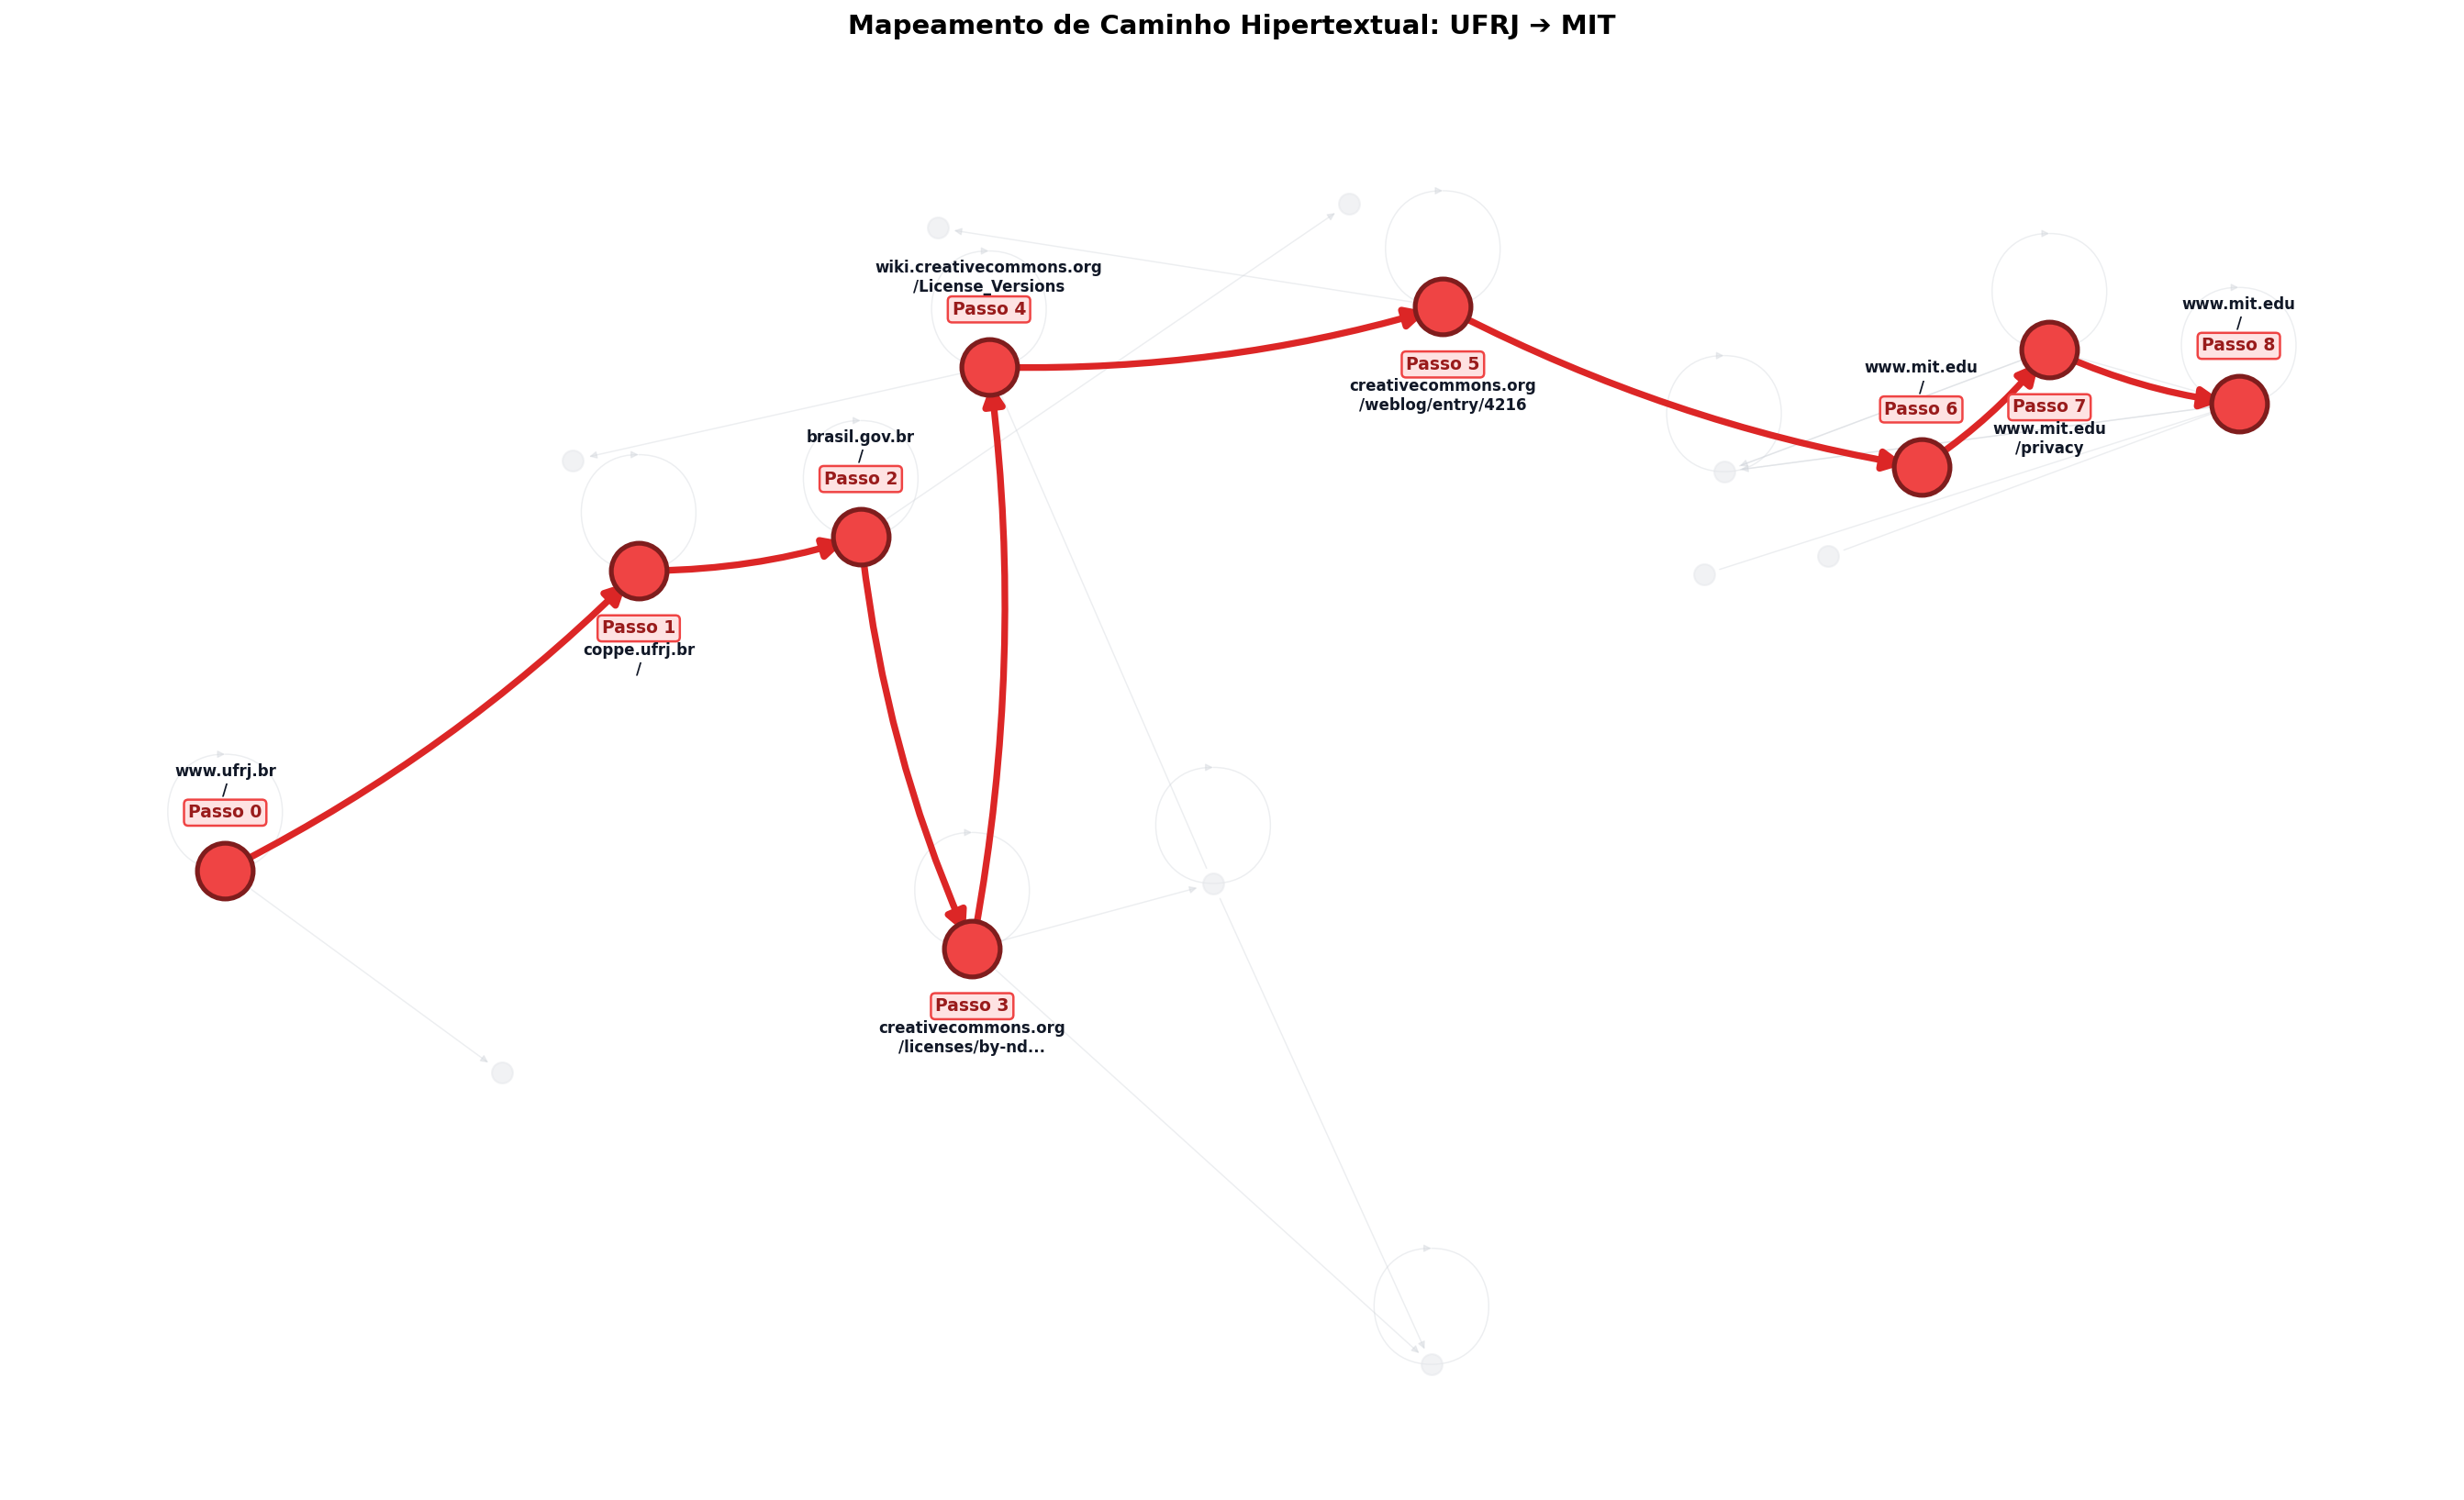

In [23]:
# ==============================================================================
# VISUALIZAÇÃO OTIMIZADA: SEM SOBREPOSIÇÃO DE NÓS E RÓTULOS
# ==============================================================================
import matplotlib.pyplot as plt
import networkx as nx
from urllib.parse import urlparse

# 1. Carrega todas as arestas do SQLite para o NetworkX
cursor = db_conn.cursor()
cursor.execute("SELECT source_url, target_url FROM edges")
full_graph = nx.DiGraph()
for src, tgt in cursor.fetchall():
    full_graph.add_edge(src, tgt)

start_node = normalize_url(START_URL)
target_node = normalize_url(TARGET_URL)

# 2. Obtém o menor caminho
try:
    if crawler.intersection_node and nx.has_path(full_graph, start_node, crawler.intersection_node) and nx.has_path(full_graph, crawler.intersection_node, target_node):
        p1 = nx.shortest_path(full_graph, source=start_node, target=crawler.intersection_node)
        p2 = nx.shortest_path(full_graph, source=crawler.intersection_node, target=target_node)
        raw_path = p1[:-1] + p2
    else:
        raw_path = nx.shortest_path(full_graph, source=start_node, target=target_node)
except Exception:
    raw_path = [
        "https://www.ufrj.br/",
        "https://coppe.ufrj.br/",
        "http://brasil.gov.br/",
        "https://creativecommons.org/licenses/by-nd/3.0/deed.pt_BR",
        "https://wiki.creativecommons.org/License_Versions",
        "http://creativecommons.org/weblog/entry/4216",
        "http://www.mit.edu/"
    ]

# 3. Remove ciclos e redundâncias finais (ex: mit.edu -> privacy -> mit.edu)
dedup_path = []
for node in raw_path:
    if node in dedup_path:
        # Corta ciclo voltando para onde já passou
        idx = dedup_path.index(node)
        dedup_path = dedup_path[:idx + 1]
    else:
        dedup_path.append(node)

path = dedup_path
path_nodes = set(path)
path_edges = list(zip(path[:-1], path[1:]))

# 4. Cria subgrafo com vizinhança controlada (apenas 2 vizinhos para reduzir poluição)
subgraph_nodes = set(path_nodes)
for node in path_nodes:
    if node in full_graph:
        subgraph_nodes.update(list(full_graph.successors(node))[:2])
        subgraph_nodes.update(list(full_graph.predecessors(node))[:2])

sub_G = full_graph.subgraph(subgraph_nodes).copy()

# 5. Layout com força de repulsão alta (k maior e mais iterações)
pos = nx.spring_layout(sub_G, k=3.2 / (len(sub_G.nodes) ** 0.35), iterations=250, seed=100)

# Ajusta manualmente o espaçamento da cadeia do caminho para evitar nós colados
for i, node in enumerate(path):
    # Dá um leve deslocamento guiado da esquerda para a direita ao longo dos passos
    base_x, base_y = pos[node]
    pos[node] = (base_x * 0.7 + (i / len(path)) * 1.5 - 0.75, base_y * 1.2)

# 6. Renderização
plt.figure(figsize=(18, 11), dpi=150)

# Nós de contexto (cinza claro) e do Caminho (vermelho vivo)
context_nodes = [n for n in sub_G.nodes if n not in path_nodes]
nx.draw_networkx_nodes(sub_G, pos, nodelist=context_nodes, node_color="#E5E7EB", node_size=120, alpha=0.5)
nx.draw_networkx_nodes(sub_G, pos, nodelist=path, node_color="#EF4444", node_size=850, edgecolors="#7F1D1D", linewidths=2.5)

# Arestas
context_edges = [e for e in sub_G.edges if e not in set(path_edges)]
nx.draw_networkx_edges(sub_G, pos, edgelist=context_edges, edge_color="#D1D5DB", width=0.7, alpha=0.4, arrows=True, arrowsize=8)
nx.draw_networkx_edges(
    sub_G, pos,
    edgelist=path_edges,
    edge_color="#DC2626",
    width=3.5,
    arrows=True,
    arrowsize=22,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.08"
)

# Rótulos dos nós e caixas de "Passo X" com posições alternadas para não colidir
for step_idx, node in enumerate(path):
    x, y = pos[node]
    parsed = urlparse(node)
    path_abbrev = parsed.path if len(parsed.path) <= 18 else parsed.path[:15] + "..."
    if not path_abbrev:
        path_abbrev = "/"

    # Alterna rótulo acima/abaixo para evitar colisão sequencial
    v_offset = 0.075 if step_idx % 2 == 0 else -0.075

    # Caixa indicadora do Passo
    plt.text(
        x, y + v_offset,
        f"Passo {step_idx}",
        fontsize=9,
        fontweight="bold",
        color="#991B1B",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="#FEE2E2", ec="#EF4444", lw=1.2)
    )

    # Texto com a URL simplificada
    plt.text(
        x, y + (v_offset * 1.55),
        f"{parsed.netloc}\n{path_abbrev}",
        fontsize=8,
        fontweight="semibold",
        color="#111827",
        ha="center",
        va="center"
    )

plt.title("Mapeamento de Caminho Hipertextual: UFRJ ➔ MIT", fontsize=14, fontweight="bold", pad=25)
plt.axis("off")
plt.tight_layout()
plt.show()

# Questão 6

In [1]:
def permuta(seq, atual=None):
    atual = atual or []
    if not seq:
        print(*atual); return
    for i in range(len(seq)):
        permuta(seq[:i] + seq[i+1:], atual + [seq[i]])

permuta([1, 2, 3])

1 2 3
1 3 2
2 1 3
2 3 1
3 1 2
3 2 1


## Qual n promove possibilidades de permutações que superam a quantidade de átomos no universo observável

In [2]:
import math
def menor_n(limite):
    n = 1
    while math.factorial(n) <= limite:
        n += 1
    return n
print("Passa o número de átomos do universo com:",menor_n(10**80))   # -> 59

Passa o número de átomos do universo com: 59


## Tempo de Execução

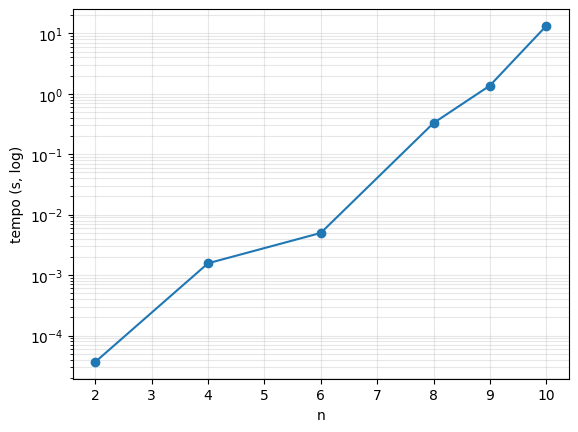

In [3]:
import os, time
from itertools import permutations

def tempo(n):
    dn = open(os.devnull, "w")
    t0 = time.perf_counter()
    for p in permutations(range(1, n + 1)):
        print(*p, file=dn)
    dn.close()
    return time.perf_counter() - t0

ns = [2, 4, 6, 8, 9, 10]
ts = [tempo(n) for n in ns]

import matplotlib.pyplot as plt
plt.plot(ns, ts, "o-"); plt.yscale("log")
plt.xlabel("n"); plt.ylabel("tempo (s, log)"); plt.grid(True, which="both", alpha=.3)
plt.show()

O tempo cresce como Θ(n·n!): em escala log a curva é côncava pra cima (mais que exponencial). O trecho n=2..6 é quase plano por overhead fixo; de n=8 em diante o fatorial domina. O salto n=9→n=10 (\~1,3s → \~13s, \~10x) bate com a razão teórica (n+1)²/n. Maior n executável na prática: 10 (\~13s); n=11 já passa de 2min. Muito antes do limite da parte 2 (n≈59).